In [ ]:
#Conexión con Google Drive para trabajar con los archivos almacenados
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

Your runtime has 13.6 gigabytes of available RAM

Not using a high-RAM runtime


In [ ]:
#Librerías importadas
import pandas as pd
import numpy as np
import re
import regex

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

from analisisFraseologico import *

#from sklearn.linear_model import LogisticRegression
#from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#from evaluate import load
#from datasets import load_dataset
from tqdm import tqdm
tqdm.pandas() # Inicializar tqdm para pandas
from tqdm.notebook import tqdm as notebook_tqdm

from nltk import sent_tokenize, word_tokenize, Text
from nltk.probability import FreqDist
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize

import joblib
import os
import gc

import shutil
import matplotlib.pyplot as plt
import seaborn as sns


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
path = "/content/drive/MyDrive/Titulacion/DatasetsFinales/"

In [ ]:
#Cargar la caracteristicas del nuevo archvio con df_train
df_train = pd.read_json(path + "df_train2_feat.jsonl", orient='records', lines=True)

In [ ]:
df_train

,id,label,transcription,transcription_processed,MeanWordLen,LexicalDiversity,MeanSentenceLen,StdevSentenceLen,MeanParagraphLen,DocumentLen,...,y claro,y yo soy el papa,ya que estamos,total_satire_words,avg_depth,avg_length,Flesch Score,Lexical Entropy,Syntactic Repetition,Unusual Word Frequency
0,5eef381b-7c3102ad.mp3,1,"Yo creo que ya lo dice la propia frase, es pri...","creer decir propio frase , privar , cada hacer...",4.761905,85.714286,29.000000,0.000000,29,136,...,0,0,0,0,2.000000,86.000000,107.57,3.97,0.28,0.50
1,3db0b886-434a22fd.mp3,0,"El presidente de Estados Unidos, Barack Obama,...","presidente unidos , barack obama , prometer añ...",6.192308,100.000000,15.500000,1.500000,31,195,...,0,0,0,0,3.500000,41.500000,84.46,4.74,0.26,0.50
2,1e3fd1a7-dfd534d8.mp3,1,El presidente Andrés Manuel López Obrador visi...,presidente andrés manuel lópez obrador visitar...,6.413793,86.206897,16.000000,5.000000,32,219,...,0,0,0,0,3.000000,38.000000,65.54,4.66,0.16,0.63
3,2f593981-4087fa79.mp3,1,"La sedición, porque inflación puede haber en c...","sedición , inflación poder haber cualquiera mo...",6.615385,84.615385,16.500000,3.500000,33,210,...,0,0,0,0,1.000000,52.000000,92.32,4.39,0.21,0.62
4,815c0b94-1002ecaa.mp3,0,Frenar la escalada de violencia en Gaza es una...,frenar escalada violencia gaza prioridad . min...,6.838710,96.774194,8.750000,3.897114,35,247,...,0,0,0,0,2.250000,17.250000,61.52,4.84,0.26,0.52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,3982793b-e3c0ec4a.mp3,0,Pero la oficina del presidente francés dice qu...,oficina presidente francés decir espíritu inic...,6.684211,94.736842,14.333333,7.133645,43,299,...,0,0,0,0,2.000000,43.333333,71.74,5.18,0.21,0.55
5996,f0442261-0348093a.mp3,1,No sé cómo se dice en castellano. Está siendo ...,"saber cómo decir castellano . ser fucking , fu...",5.736842,84.210526,6.400000,2.154066,32,151,...,0,0,0,2,2.000000,17.250000,121.33,4.05,0.41,0.62
5997,64ea7bec-c46cfd71.mp3,0,"Sí, porque Rajoy dice que la razón de que esa ...",", rajoy decir razón calificación crediticio ca...",7.435897,89.743590,11.750000,2.861381,47,341,...,0,0,0,0,2.750000,27.750000,64.71,5.04,0.21,0.49
5998,59a76f7b-75cc8d14.mp3,0,Francisco era conocido como Jimmy entre los se...,francisco conocer jimmy seguidor deportivo . a...,6.500000,96.875000,6.500000,2.061553,39,248,...,0,0,0,0,0.833333,11.166667,77.59,4.84,0.23,0.52


In [ ]:
#Listar todas las columnas de df_train

print(df_train.columns.tolist())


['id', 'label', 'transcription', 'transcription_processed', 'MeanWordLen', 'LexicalDiversity', 'MeanSentenceLen', 'StdevSentenceLen', 'MeanParagraphLen', 'DocumentLen', 'WordsPerText', 'SentencesPerText', 'MeanDifferenceSentenceLengths', 'num_words', 'num_chars', 'exclamations', 'uppercase_ratio', 'polarity', 'subjectivity', 'Polaridad_VADER', 'irony_score', 'prop_ADV', 'prop_NOUN', 'prop_VERB', 'prop_ADJ', 'rhetorical_questions', 'metaphors', 'satire_words_density', 'a fin de cuentas', 'absolutamente', 'absurdo', 'ah si', 'ahora resulta que', 'aparentemente', 'asi estamos', 'asombrosamente', 'asombroso', 'asquerosamente', 'aunque parezca increible', 'brillante', 'casi siempre', 'ciertamente', 'claramente', 'claro', 'claro que si', 'como bien sabemos', 'como era de esperarse', 'como si', 'como siempre', 'como todo esta bajo control', 'completamente', 'convenientemente', 'curiosamente', 'dado que todo funciona tan bien', 'de forma exagerada', 'de forma innecesaria', 'de manera sorprende

In [ ]:
#En otro dataframe separar a partir de la columna 4 en adelande de df_train

df_train_features = df_train.iloc[:, 4:]

df_train_features


,MeanWordLen,LexicalDiversity,MeanSentenceLen,StdevSentenceLen,MeanParagraphLen,DocumentLen,WordsPerText,SentencesPerText,MeanDifferenceSentenceLengths,num_words,...,y claro,y yo soy el papa,ya que estamos,total_satire_words,avg_depth,avg_length,Flesch Score,Lexical Entropy,Syntactic Repetition,Unusual Word Frequency
0,4.761905,85.714286,29.000000,0.000000,29,136,21,1,0.000000,29,...,0,0,0,0,2.000000,86.000000,107.57,3.97,0.28,0.50
1,6.192308,100.000000,15.500000,1.500000,31,195,26,2,-3.000000,31,...,0,0,0,0,3.500000,41.500000,84.46,4.74,0.26,0.50
2,6.413793,86.206897,16.000000,5.000000,32,219,29,2,-10.000000,32,...,0,0,0,0,3.000000,38.000000,65.54,4.66,0.16,0.63
3,6.615385,84.615385,16.500000,3.500000,33,210,26,2,7.000000,33,...,0,0,0,0,1.000000,52.000000,92.32,4.39,0.21,0.62
4,6.838710,96.774194,8.750000,3.897114,35,247,31,4,-0.333333,35,...,0,0,0,0,2.250000,17.250000,61.52,4.84,0.26,0.52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,6.684211,94.736842,14.333333,7.133645,43,299,38,3,6.000000,43,...,0,0,0,0,2.000000,43.333333,71.74,5.18,0.21,0.55
5996,5.736842,84.210526,6.400000,2.154066,32,151,19,5,1.000000,32,...,0,0,0,2,2.000000,17.250000,121.33,4.05,0.41,0.62
5997,7.435897,89.743590,11.750000,2.861381,47,341,39,4,0.666667,47,...,0,0,0,0,2.750000,27.750000,64.71,5.04,0.21,0.49
5998,6.500000,96.875000,6.500000,2.061553,39,248,32,6,-0.600000,39,...,0,0,0,0,0.833333,11.166667,77.59,4.84,0.23,0.52


In [ ]:
#Registros de cada etiqueta
y = df_train['label']
y.value_counts()

,count
label,
0,3168
1,2832


In [ ]:
# Modelos de clasificación tradicionales
SVC_model = LinearSVC(dual='auto')
SVM_model = SVC(kernel='linear', probability=True)
RF_model = RandomForestClassifier(n_estimators=100, random_state=42)
MLP_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500)
XGB_model = XGBClassifier(n_estimators=100)

models = {
    'SVC': SVC_model,
    'SVM': SVM_model,
    'RF': RF_model,
    'MLP': MLP_model,
    'XGB': XGB_model,
    'VC': VotingClassifier(estimators=[('RF', RF_model),
                                       ('SVM', SVM_model), ('MLP', MLP_model),
                                       ('XGB', XGB_model)], voting='soft')
}

In [ ]:
  #tfidf_test = vectorizer.transform(df_test['transcription_processed'])

  #categorias_df_train = df_train['caracteristicas'].apply(pd.Series).fillna(0)
  #categorias_df_test = df_test['caracteristicas'].apply(pd.Series).fillna(0)
   #tfidf_df_test = pd.DataFrame(tfidf_test.toarray())
# Define max_features values to iterate through
max_features_values = [500, 1000, 2000, 3000, 5000]

In [ ]:

all_results = []

for max_features in notebook_tqdm(max_features_values, desc="Max Features"):
  print(f"Processing with max_features = {max_features}")

  vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=(1, 2))

  tfidf_train= vectorizer.fit_transform(df_train['transcription_processed'])


  tfidf_df_train = pd.DataFrame(tfidf_train.toarray())


  combined_df_train = pd.concat([tfidf_df_train, df_train_features],  axis=1)
  X = combined_df_train
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

  # Convertir todos los nombres de columna en cadenas antes de escalar.
  X_train.columns = X_train.columns.astype(str)
  X_test.columns = X_test.columns.astype(str)
  #combined_df_test.columns = combined_df_test.columns.astype(str)

  # Antes de aplicar SMOTE
  imputer = SimpleImputer(strategy='mean')  # También puede usarse "mediana" u otras estrategias.
  X_train_imputed = imputer.fit_transform(X_train)
  X_test_imputed = imputer.transform(X_test)

  # Inicializar MinMaxScaler
  scaler = MinMaxScaler()
  scaled_text_x_train = scaler.fit_transform(X_train_imputed)
  scaled_text_x_test = scaler.transform(X_test_imputed)
  #scaled_text_x_test = scaler.transform(combined_df_test)

  smote = SMOTE(random_state=42)
  X_train_balanced, y_train_balanced = smote.fit_resample(scaled_text_x_train, y_train)

  del combined_df_train
  #del combined_df_test
  del tfidf_df_train
  #del tfidf_df_test
  #del df_train_features
  #del df_test_features

  del tfidf_train
  #del tfidf_test
  gc.collect()

  #X = scaled_text_x_train
  #X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

  #smote = SMOTE(random_state=42)
  #X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)


  results = []
  for name, model in notebook_tqdm(models.items(), desc="Training Models"):
      model.fit(X_train_balanced, y_train_balanced)
      #model.fit(scaled_text_x_train, y_train_balanced)

      model_name = name
      model_folder = f"/content/drive/MyDrive/Titulacion/Entrenamiento/ConLema/{model_name}max_features{max_features}"

      # Crear la carpeta del modelo si no existe.
      os.makedirs(model_folder, exist_ok=True)
      print(f"Processing model: {model_name} with max_features = {max_features}")

      # Guardar el modelo, el vectorizador y el escalador en la carpeta del modelo.
      joblib.dump(model, os.path.join(model_folder, 'model.pkl'))
      joblib.dump(vectorizer, os.path.join(model_folder, 'vectorizer.pkl'))
      joblib.dump(scaler, os.path.join(model_folder, 'scaler.pkl'))
      joblib.dump(imputer, os.path.join(model_folder, 'imputer.pkl'))
      #print(f"Model, vectorizer, and scaler saved to: {model_folder}")

      #y_pred = model.predict(X_test)
      y_pred = model.predict(scaled_text_x_test)
      report = classification_report(y_test, y_pred, output_dict=True, zero_division='warn')
      results.append({
          'Model': name,
          'Accuracy': accuracy_score(y_test, y_pred),
          'Precision': report['macro avg']['precision'],
          'Recall': report['macro avg']['recall'],
          'F1-score': report['macro avg']['f1-score'],
          'max_features': max_features
      })
  all_results.extend(results)

Max Features:   0%|          | 0/5 [00:00<?, ?it/s]

Processing with max_features = 500


Training Models:   0%|          | 0/6 [00:00<?, ?it/s]

Processing model: SVC with max_features = 500
Processing model: SVM with max_features = 500
Processing model: RF with max_features = 500
Processing model: MLP with max_features = 500
Processing model: XGB with max_features = 500
Processing model: VC with max_features = 500
Processing with max_features = 1000


Training Models:   0%|          | 0/6 [00:00<?, ?it/s]

...

Processing model: SVC with max_features = 2000
Processing model: SVM with max_features = 2000
Processing model: RF with max_features = 2000
Processing model: MLP with max_features = 2000
Processing model: XGB with max_features = 2000
Processing model: VC with max_features = 2000
Processing with max_features = 3000


Training Models:   0%|          | 0/6 [00:00<?, ?it/s]

Processing model: SVC with max_features = 3000
Processing model: SVM with max_features = 3000
Processing model: RF with max_features = 3000
Processing model: MLP with max_features = 3000
Processing model: XGB with max_features = 3000
Processing model: VC with max_features = 3000
Processing with max_features = 5000


Training Models:   0%|          | 0/6 [00:00<?, ?it/s]

Processing model: SVC with max_features = 5000
Processing model: SVM with max_features = 5000
Processing model: RF with max_features = 5000
Processing model: MLP with max_features = 5000
Processing model: XGB with max_features = 5000
Processing model: VC with max_features = 5000


In [ ]:
#Resultados de las experimentaciones con distintas cantidades máximas de n-gramas
results_df = pd.DataFrame(all_results)
results_df

,Model,Accuracy,Precision,Recall,F1-score,max_features
0,SVC,0.890000,0.890096,0.889401,0.889686,500
1,SVM,0.885833,0.885797,0.885339,0.885538,500
2,RF,0.882500,0.882453,0.881999,0.882196,500
3,MLP,0.896667,0.897213,0.895781,0.896293,500
4,XGB,0.897500,0.897990,0.896653,0.897140,500
5,VC,0.905000,0.905066,0.904507,0.904746,500
6,SVC,0.881667,0.881382,0.882028,0.881548,1000
7,SVM,0.895000,0.894748,0.894862,0.894802,1000
8,RF,0.887500,0.887723,0.886783,0.887148,1000
9,MLP,0.876667,0.876455,0.877168,0.876568,1000


In [ ]:
# Se ordenan los resultados por F1-Score en orden descendente y luego por accuracy.
top_10_models = results_df.sort_values(by=['F1-score', 'Accuracy'], ascending=[False, False]).head(10)

top_10_models


,Model,Accuracy,Precision,Recall,F1-score,max_features
23,VC,0.920000,0.919708,0.920138,0.919882,3000
17,VC,0.920000,0.919754,0.919988,0.919861,2000
11,VC,0.919167,0.918905,0.919191,0.919032,1000
29,VC,0.913333,0.913157,0.913157,0.913157,5000
10,XGB,0.912500,0.913071,0.911684,0.912193,1000
22,XGB,0.910000,0.911057,0.908916,0.909618,3000
28,XGB,0.909167,0.910644,0.907893,0.908730,5000
16,XGB,0.905833,0.906498,0.904928,0.905484,2000
5,VC,0.905000,0.905066,0.904507,0.904746,500
4,XGB,0.897500,0.897990,0.896653,0.897140,500


In [ ]:
# Se ordena el DataFrame por F1-Score orden descendente, y se seleccionan los 10 primeros.
top_10_models = results_df.sort_values(by='F1-score', ascending=False).head(10)

top_10_models


,Model,Accuracy,Precision,Recall,F1-score,max_features
23,VC,0.920000,0.919708,0.920138,0.919882,3000
17,VC,0.920000,0.919754,0.919988,0.919861,2000
11,VC,0.919167,0.918905,0.919191,0.919032,1000
29,VC,0.913333,0.913157,0.913157,0.913157,5000
10,XGB,0.912500,0.913071,0.911684,0.912193,1000
22,XGB,0.910000,0.911057,0.908916,0.909618,3000
28,XGB,0.909167,0.910644,0.907893,0.908730,5000
16,XGB,0.905833,0.906498,0.904928,0.905484,2000
5,VC,0.905000,0.905066,0.904507,0.904746,500
4,XGB,0.897500,0.897990,0.896653,0.897140,500


In [ ]:
import shutil
import os

# Definición del path del directorio
dir_path = "/content/drive/MyDrive/Titulacion/Entrenamiento/ModeloTodo/"

# Se comprueba si el directorio existe y no está vacío.
if os.path.exists(dir_path) and os.listdir(dir_path):
    # Se borra el contenido del directorio
    shutil.rmtree(dir_path)
    print(f"Directory '{dir_path}' and its contents have been deleted.")

    #Se vuelve a crear el directorio vacío
    os.makedirs(dir_path, exist_ok=True)
    print(f"Empty directory '{dir_path}' has been recreated.")

elif os.path.exists(dir_path):
    print(f"Directory '{dir_path}' exists but is empty.")

else:
    print(f"Directory '{dir_path}' does not exist.")
    os.makedirs(dir_path, exist_ok=True)
    print(f"Empty directory '{dir_path}' has been created.")

Directory '/content/drive/MyDrive/Titulacion/Entrenamiento/ModeloTodo/' exists but is empty.


In [ ]:
# Se guardan los 5 modelos principales basados en f1_macro en un archivo en Google Drive.
top_5_models = results_df.sort_values(by='F1-score', ascending=False).head(5)

In [ ]:
top_5_models

,Model,Accuracy,Precision,Recall,F1-score,max_features
23,VC,0.920000,0.919708,0.920138,0.919882,3000
17,VC,0.920000,0.919754,0.919988,0.919861,2000
11,VC,0.919167,0.918905,0.919191,0.919032,1000
29,VC,0.913333,0.913157,0.913157,0.913157,5000
10,XGB,0.912500,0.913071,0.911684,0.912193,1000


In [ ]:
# Se guardan los 5 modelos principales en un archivo CSV en Google Drive.
top_5_models.to_csv("/content/drive/MyDrive/Titulacion/Entrenamiento/ModeloTodo/top_5_models.csv", index=False)


In [ ]:
# Leer top_5_models.csv

import pandas as pd

# Cargar el archivo CSV en un DataFrame de pandas.
top_5_models = pd.read_csv("/content/drive/MyDrive/Titulacion/Entrenamiento/ModeloTodo/top_5_models.csv")

# Visualizar los 5 mejores modelos.
top_5_models


,Model,Accuracy,Precision,Recall,F1-score,max_features
0,VC,0.920000,0.919708,0.920138,0.919882,3000
1,VC,0.920000,0.919754,0.919988,0.919861,2000
2,VC,0.919167,0.918905,0.919191,0.919032,1000
3,VC,0.913333,0.913157,0.913157,0.913157,5000
4,XGB,0.912500,0.913071,0.911684,0.912193,1000




---


##HASTA AHÍ PORQUE YA SE LOS TRES MEJORES MODELOS

In [ ]:
# Leer top_5_models.csv

# Se carga el CSV
top_5_models = pd.read_csv("/content/drive/MyDrive/Titulacion/Entrenamiento/ModeloTodo/top_5_models.csv")

# Se visualizan los mejores 5 modelos
top_5_models

,Model,Accuracy,Precision,Recall,F1-score,max_features
0,VC,0.920000,0.919708,0.920138,0.919882,3000
1,VC,0.920000,0.919754,0.919988,0.919861,2000
2,VC,0.919167,0.918905,0.919191,0.919032,1000
3,VC,0.913333,0.913157,0.913157,0.913157,5000
4,XGB,0.912500,0.913071,0.911684,0.912193,1000


In [ ]:
#ESTE OK PARA PREDECIR CON NUEVO TEST
#Predecir con los modelos almacendos segun top_5_models

import pandas as pd
import joblib
import numpy as np
from sklearn.metrics import classification_report, accuracy_score
import shutil
import os


#AQUÍ DEBO CARGAR EL TEST QUE QUIERO PREDECIR

path = "/content/drive/MyDrive/Titulacion/DatasetsFinales/"

# Cargar los datos de prueba
#df_test = pd.read_json(path + "df_test_feat.jsonl", orient='records', lines=True)
df_test = pd.read_json(path + "df_test2_feat.jsonl", orient='records', lines=True)
#df_test = pd.read_json(path + "df_test2_featselect2.jsonl", orient='records', lines=True)
df_test

,id,label,transcription,transcription_processed,MeanWordLen,LexicalDiversity,MeanSentenceLen,StdevSentenceLen,MeanParagraphLen,DocumentLen,...,y claro,y yo soy el papa,ya que estamos,total_satire_words,avg_depth,avg_length,Flesch Score,Lexical Entropy,Syntactic Repetition,Unusual Word Frequency
0,2abcfbec-b59cdc92.mp3,0,"Para algunos deportados, mudarse a dormir aquí...","deportado , mudar él dormir aquí último recurs...",5.400000,96.666667,12.000000,2.943920,36,201,...,0,0,0,0,1.000000,37.333333,99.26,4.85,0.19,0.42
1,9c3f7d29-727fa523.mp3,1,Pues solo cuando me subí a un escenario a hace...,pues solo subir escenario hacer monólogo viven...,6.172414,82.758621,17.000000,9.000000,34,216,...,0,0,0,0,9.000000,46.000000,79.10,4.54,0.24,0.65
2,0e415924-8b600d71.mp3,0,Se trata de los máximos responsables de la ban...,"tratar máximo responsable banda terrorista , i...",6.977778,97.777778,8.142857,2.531435,57,376,...,0,0,0,1,2.857143,14.714286,84.35,5.39,0.21,0.62
3,1f09022d-81190f9b.mp3,0,En la maniobra final de aterrizaje algo se com...,maniobra final aterrizaje complicar ultraliger...,7.222222,100.000000,8.800000,2.785678,44,307,...,0,0,0,0,2.000000,20.200000,75.81,5.09,0.25,0.68
4,aa352c05-532b33cc.mp3,1,manejar el hate y digo porque por lo general e...,manejar hate decir general odiar bien pendejo ...,6.307692,100.000000,26.000000,0.000000,26,189,...,0,0,0,1,1.000000,113.000000,60.32,4.70,0.23,0.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,3826f75b-ba14c8e5.mp3,1,en Mojama y fui a verlo porque a mí me dicen h...,mojama ver él decir mojama ir directamente,5.142857,85.714286,7.000000,0.000000,7,42,...,0,0,0,0,0.000000,10.000000,71.13,2.52,0.43,0.50
92,86ae0b91-e42d0ad0.mp3,1,"Y ya al volver, o sea, todo ha ido bien, y ya ...","volver , , ir bien , volver , agredir aeropuer...",5.454545,72.727273,7.666667,7.318166,23,94,...,0,0,0,0,1.000000,35.000000,152.04,3.22,0.52,0.54
93,4bfde41f-989b722b.mp3,1,Ayer me las cortaron. Porque sabías que venías...,"ayer cortar . sabía veniar tele yo , cariño . ...",5.280000,92.000000,5.000000,2.329929,35,170,...,0,0,0,0,1.142857,8.571429,106.33,4.51,0.29,0.56
94,53b63159-64f00c13.mp3,0,El niño británico afectado con un tumor cerebr...,niño británico afectado tumor cerebral padre l...,6.366667,96.666667,11.333333,4.027682,34,226,...,0,0,0,0,3.000000,25.000000,70.49,4.89,0.21,0.35


Processing model: VC with max_features = 3000
                   id     task_1     task_2
0   2abcfbec-b59cdc92  no-satire  no-satire
1   9c3f7d29-727fa523     satire     satire
2   0e415924-8b600d71  no-satire  no-satire
3   1f09022d-81190f9b  no-satire  no-satire
4   aa352c05-532b33cc     satire     satire
..                ...        ...        ...
91  3826f75b-ba14c8e5     satire     satire
92  86ae0b91-e42d0ad0     satire     satire
93  4bfde41f-989b722b     satire     satire
94  53b63159-64f00c13  no-satire  no-satire
95  5b97747c-a4aca1b4     satire     satire

[96 rows x 3 columns]
{'0': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 48.0}, '1': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 48.0}, 'accuracy': 1.0, 'macro avg': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 96.0}, 'weighted avg': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 96.0}}


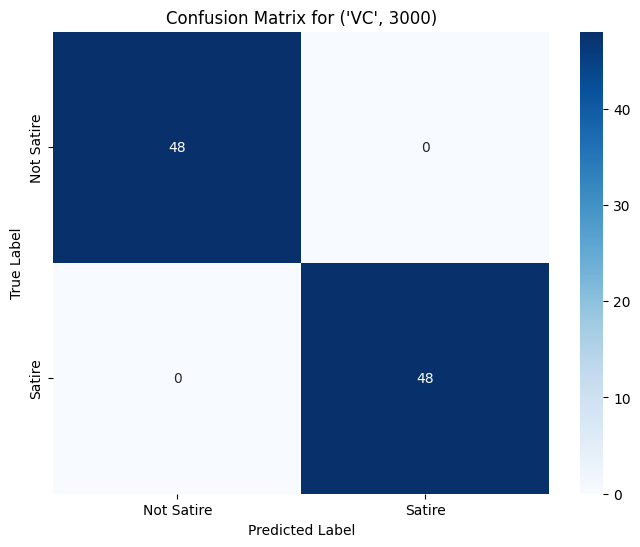

Processing model: VC with max_features = 2000
                   id     task_1     task_2
0   2abcfbec-b59cdc92  no-satire  no-satire
1   9c3f7d29-727fa523     satire     satire
2   0e415924-8b600d71  no-satire  no-satire
3   1f09022d-81190f9b  no-satire  no-satire
4   aa352c05-532b33cc     satire     satire
..                ...        ...        ...
91  3826f75b-ba14c8e5     satire     satire
92  86ae0b91-e42d0ad0     satire     satire
93  4bfde41f-989b722b     satire     satire
94  53b63159-64f00c13  no-satire  no-satire
95  5b97747c-a4aca1b4     satire     satire

[96 rows x 3 columns]
{'0': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 48.0}, '1': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 48.0}, 'accuracy': 1.0, 'macro avg': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 96.0}, 'weighted avg': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 96.0}}


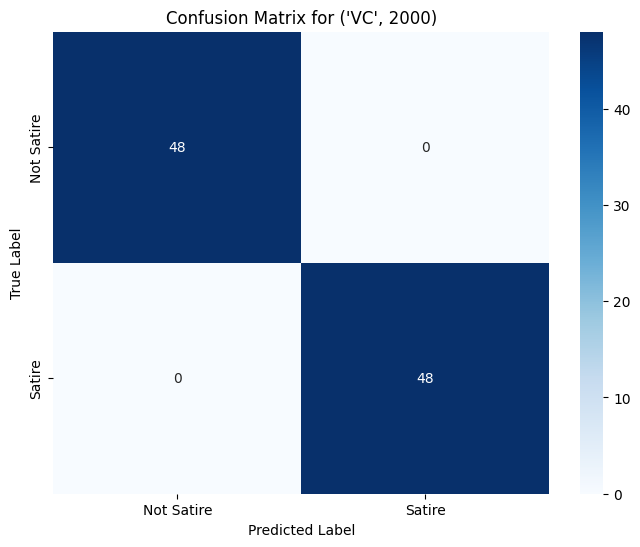

Processing model: VC with max_features = 1000
                   id     task_1     task_2
0   2abcfbec-b59cdc92  no-satire  no-satire
1   9c3f7d29-727fa523     satire     satire
2   0e415924-8b600d71  no-satire  no-satire
3   1f09022d-81190f9b  no-satire  no-satire
4   aa352c05-532b33cc     satire     satire
..                ...        ...        ...
91  3826f75b-ba14c8e5     satire     satire
92  86ae0b91-e42d0ad0     satire     satire
93  4bfde41f-989b722b     satire     satire
94  53b63159-64f00c13  no-satire  no-satire
95  5b97747c-a4aca1b4     satire     satire

[96 rows x 3 columns]
{'0': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 48.0}, '1': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 48.0}, 'accuracy': 1.0, 'macro avg': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 96.0}, 'weighted avg': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 96.0}}


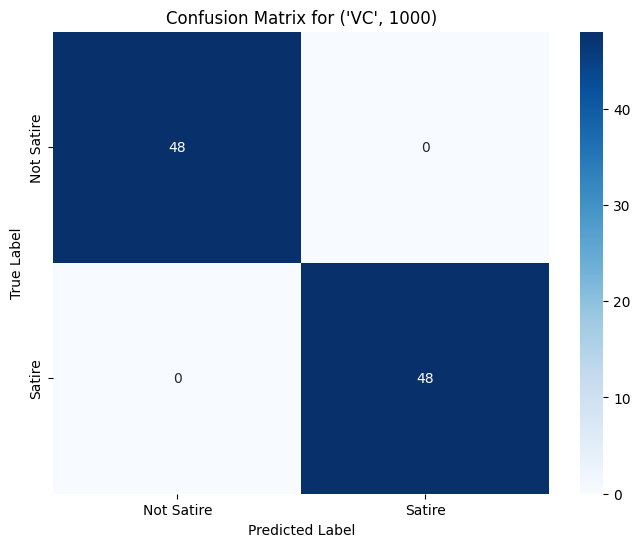

Processing model: VC with max_features = 5000
                   id     task_1     task_2
0   2abcfbec-b59cdc92  no-satire  no-satire
1   9c3f7d29-727fa523     satire     satire
2   0e415924-8b600d71  no-satire  no-satire
3   1f09022d-81190f9b  no-satire  no-satire
4   aa352c05-532b33cc     satire     satire
..                ...        ...        ...
91  3826f75b-ba14c8e5     satire     satire
92  86ae0b91-e42d0ad0     satire     satire
93  4bfde41f-989b722b     satire     satire
94  53b63159-64f00c13  no-satire  no-satire
95  5b97747c-a4aca1b4     satire     satire

[96 rows x 3 columns]
{'0': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 48.0}, '1': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 48.0}, 'accuracy': 1.0, 'macro avg': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 96.0}, 'weighted avg': {'precision': 1.0, 'recall': 1.0, 'f1-score': 1.0, 'support': 96.0}}


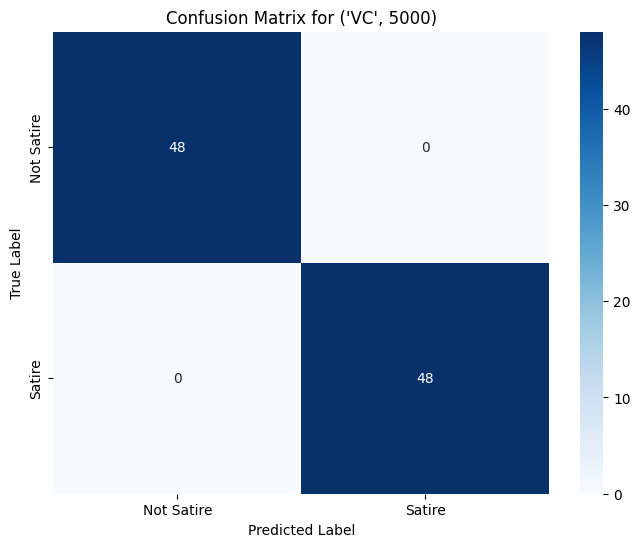

Processing model: XGB with max_features = 1000
                   id     task_1     task_2
0   2abcfbec-b59cdc92  no-satire  no-satire
1   9c3f7d29-727fa523     satire     satire
2   0e415924-8b600d71  no-satire  no-satire
3   1f09022d-81190f9b  no-satire  no-satire
4   aa352c05-532b33cc     satire     satire
..                ...        ...        ...
91  3826f75b-ba14c8e5     satire     satire
92  86ae0b91-e42d0ad0     satire     satire
93  4bfde41f-989b722b     satire     satire
94  53b63159-64f00c13  no-satire  no-satire
95  5b97747c-a4aca1b4     satire     satire

[96 rows x 3 columns]
{'0': {'precision': 0.9795918367346939, 'recall': 1.0, 'f1-score': 0.9896907216494846, 'support': 48.0}, '1': {'precision': 1.0, 'recall': 0.9791666666666666, 'f1-score': 0.9894736842105263, 'support': 48.0}, 'accuracy': 0.9895833333333334, 'macro avg': {'precision': 0.9897959183673469, 'recall': 0.9895833333333333, 'f1-score': 0.9895822029300054, 'support': 96.0}, 'weighted avg': {'precision': 0.98

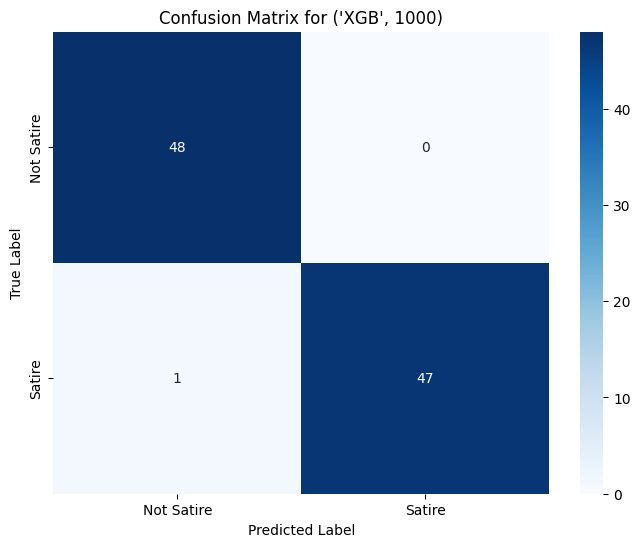

,Model,Accuracy,Recall,F1-score,max_features
0,VC,1.000000,1.000000,1.000000,3000
1,VC,1.000000,1.000000,1.000000,2000
2,VC,1.000000,1.000000,1.000000,1000
3,VC,1.000000,1.000000,1.000000,5000
4,XGB,0.989583,0.989583,0.989582,1000


In [ ]:
df_test_features = df_test.iloc[:, 4:] # Suponiendo que las características comienzan a partir de la quinta columna

model_folder = "/content/drive/MyDrive/Titulacion/Entrenamiento/ConLema"

all_results = []
results = []
#predictions = []

for index, row in top_5_models.iterrows():
    model_name = row['Model']
    max_features = row['max_features']
    model_folder = f"/content/drive/MyDrive/Titulacion/Entrenamiento/ConLema/{model_name}max_features{max_features}"

    model_path = f"/content/drive/MyDrive/Titulacion/Entrenamiento/ConLema/{model_name}max_features{max_features}/model.pkl"
    vectorizer_path = f"/content/drive/MyDrive/Titulacion/Entrenamiento/ConLema/{model_name}max_features{max_features}/vectorizer.pkl"
    scaler_path = f"/content/drive/MyDrive/Titulacion/Entrenamiento/ConLema/{model_name}max_features{max_features}/scaler.pkl"
    imputer_path = f"/content/drive/MyDrive/Titulacion/Entrenamiento/ConLema/{model_name}max_features{max_features}/imputer.pkl"

    #Intentar:
    # Cargar el modelo, el vectorizador y el escalador.
    model = joblib.load(model_path)
    vectorizer = joblib.load(vectorizer_path)
    scaler = joblib.load(scaler_path)
    imputer = joblib.load(imputer_path)

    # Preprocesar los datos de prueba (igual que el entrenamiento)
    tfidf_test = vectorizer.transform(df_test['transcription_processed']) # Suponiendo que exista la columna «transcription_processed»
    tfidf_df_test = pd.DataFrame(tfidf_test.toarray())
    combined_df_test = pd.concat([tfidf_df_test, df_test_features], axis=1)
    combined_df_test.columns = combined_df_test.columns.astype(str)

    # Imputar valores perdidos (por ejemplo, sustituir NaN por 0).
    #combined_df_test = combined_df_test.fillna(0)  # Reemplazar NaN con 0
    X_test_imputed = imputer.transform(combined_df_test)

    scaled_text_x_test = scaler.transform(X_test_imputed)

    # Realizar predicciones
    print(f"Processing model: {model_name} with max_features = {max_features}")
    y_pred = model.predict(scaled_text_x_test)
    #predictions.append(y_pred)


    #Genera la salida del Workshop
    output_df = pd.DataFrame(columns=["id", "task_1", "task_2"])
    output_df["id"] = df_test["id"].str.replace ('.mp3', '', regex = False)
    output_df["task_1"] = y_pred
    output_df["task_2"] = y_pred
    output_df["task_1"] = output_df["task_1"].map({0: 'no-satire', 1: 'satire'})
    output_df["task_2"] = output_df["task_2"].map({0: 'no-satire', 1: 'satire'})
    print (output_df)
    output_df.to_csv (os.path.join(model_folder, 'results.csv'), index = False)

    report = classification_report(df_test['label'], y_pred, output_dict=True, zero_division='warn', digits=6)

    print(classification_report(df_test['label'], y_pred, output_dict=True, zero_division='warn', digits=6))

    cm = confusion_matrix(df_test['label'], y_pred)

    #Traza la matriz de confusión.
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Not Satire', 'Satire'], yticklabels=['Not Satire', 'Satire'])
    plt.title(f"Confusion Matrix for {model_name, max_features}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    results.append({
        'Model': model_name,
        'Accuracy': accuracy_score(df_test['label'], y_pred),
        'Recall': report['macro avg']['recall'],
        'F1-score': report['macro avg']['f1-score'],
        'max_features': max_features
    })

    #del combined_df_train
    del combined_df_test
    #del tfidf_df_train
    del tfidf_df_test
    #del tfidf_train
    del tfidf_test
    gc.collect()

all_results.extend(results)
results_df = pd.DataFrame(all_results).sort_values(by='F1-score', ascending=False)
top_5_models = results_df.sort_values(by='F1-score', ascending=False).head(5)
results_df


#LO QUE SIGUE ES UN EJEMPLO DE PREDICCION CARGANDO PRIMERO LOS MODELOS GUARDADOS (toca adecuarlo)